# Movie Recommendation System — 01 Exploratory Data Analysis

A **collaborative-filtering** recommender on the MovieLens (small) dataset. Users have rated movies 0.5–5.0; we want to recommend unseen movies each user will like. There is no external label — we learn purely from the **user × movie rating matrix**.

This notebook explores the ratings and the sparsity that defines the problem.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils

ratings = utils.load_ratings()
titles = utils.load_items()
print('ratings:', ratings.shape)
print('users:', ratings.user.nunique(), '| movies:', ratings.item.nunique())
ratings.head()

ratings: (100836, 3)
users: 610 | movies: 9724


,user,item,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


## 1. Rating distribution

How users score movies — are they generous or harsh?

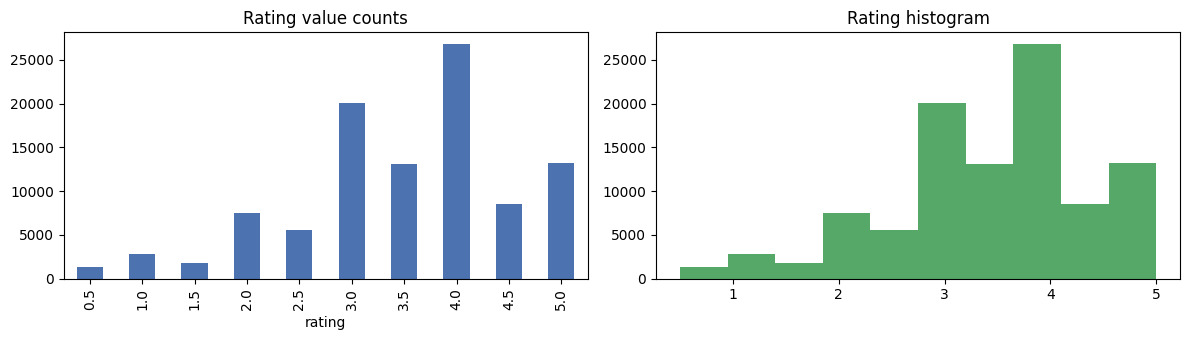

mean rating: 3.502


In [2]:
fig, ax = plt.subplots(1,2,figsize=(12,3.5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')
ax[0].set_title('Rating value counts'); ax[0].set_xlabel('rating')
ax[1].hist(ratings['rating'], bins=10, color='#55a868'); ax[1].set_title('Rating histogram')
plt.tight_layout(); plt.show()
print('mean rating:', round(ratings['rating'].mean(),3))

## 2. Activity distributions (the long tail)

Most users rate few movies and most movies get few ratings — the classic recommender long tail.

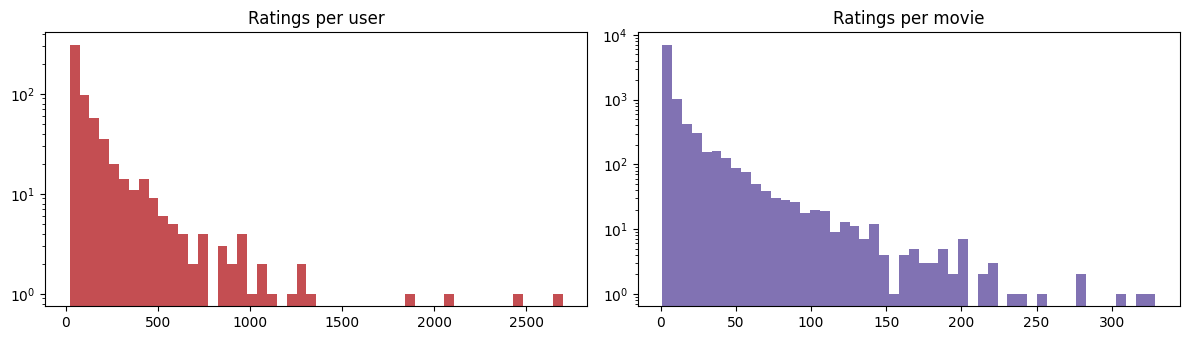

ratings per user  — median 70, max 2698
ratings per movie — median 3, max 329


In [3]:
rpu = ratings.groupby('user').size(); rpm = ratings.groupby('item').size()
fig, ax = plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(rpu, bins=50, color='#c44e52'); ax[0].set_title('Ratings per user'); ax[0].set_yscale('log')
ax[1].hist(rpm, bins=50, color='#8172b3'); ax[1].set_title('Ratings per movie'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()
print('ratings per user  — median %d, max %d' % (rpu.median(), rpu.max()))
print('ratings per movie — median %d, max %d' % (rpm.median(), rpm.max()))

## 3. Sparsity of the user-item matrix

In [4]:
n_users, n_items = ratings.user.nunique(), ratings.item.nunique()
density = len(ratings)/(n_users*n_items)
print(f'full matrix: {n_users} users x {n_items} movies = {n_users*n_items:,} cells')
print(f'observed ratings: {len(ratings):,}')
print('density: %.3f%%  (sparsity %.3f%%)' % (100*density, 100*(1-density)))

full matrix: 610 users x 9724 movies = 5,931,640 cells
observed ratings: 100,836
density: 1.700%  (sparsity 98.300%)


## 4. Most-rated and highest-rated movies

Popularity vs quality — the popularity baseline in notebook 03 leans on the most-rated column.

In [5]:
agg = ratings.groupby('item')['rating'].agg(['mean','count'])
agg['title'] = agg.index.map(titles)
print('Most-rated:'); print(agg.sort_values('count', ascending=False).head(8)[['title','count','mean']].to_string())
print('\nHighest-rated (>=50 ratings):')
print(agg[agg['count']>=50].sort_values('mean', ascending=False).head(8)[['title','count','mean']].to_string())

Most-rated:
                                          title  count      mean
item                                                            
356                         Forrest Gump (1994)    329  4.164134
318            Shawshank Redemption, The (1994)    317  4.429022
296                         Pulp Fiction (1994)    307  4.197068
593            Silence of the Lambs, The (1991)    279  4.161290
2571                         Matrix, The (1999)    278  4.192446
260   Star Wars: Episode IV - A New Hope (1977)    251  4.231076
480                        Jurassic Park (1993)    238  3.750000
110                           Braveheart (1995)    237  4.031646

Highest-rated (>=50 ratings):
                                                                             title  count      mean
item                                                                                               
318                                               Shawshank Redemption, The (1994)    317  4.429022
858    

## 5. Summary of findings

- **610 users, 9,724 movies, 100,836 ratings** — the user-item matrix is **~98.3% empty**.
- Ratings skew **high** (mean ≈ 3.5); whole and half stars both common.
- Strong **long tail**: median user rates ~70 movies, median movie gets few ratings — popularity alone will over-recommend blockbusters.
- Sparsity is the central challenge; notebook 02 restricts to the most active users / popular movies to build a workable matrix, and 03 compares CF and matrix factorization.